In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sportnews_gpt_1000.csv')

display(df.head(10), df['Kategorija'].value_counts())

,Naslov,Kategorija,Tekst
0,Goran Tomić progovorio o budućnosti: 'Ostajemo...,Nogomet,Trener Simon Rožman bio je vidljivo zadovoljan...
1,Andy Murray najavio kraj karijere: Emotivne scene,Tenis,Donna Vekić nastavlja sjajan nastup na turniru...
2,Verstappen dominira na VN Silverstone: Pobijed...,Formula 1,Velika nagrada Formule 1 u Spa-Francorchamps p...
3,Ozljeda potresla Osijek: Ivo Grbić izvan stroj...,Nogomet,Veliki derbi između Osijek i Hajduk Split priv...
4,VAR drama u HNL-u: Osijek ostao bez pobjede u ...,Nogomet,"U uzbudljivoj utakmici 1. kola HNL-a, Dinamo Z..."
5,VK Jadran Split srušio favorite i iznenadio Eu...,Vaterpolo,Hrvatska vaterpolska reprezentacija priredila ...
6,Mladi talent Istra oduševio skautere: Transfer...,Nogomet,"U uzbudljivoj utakmici 11. kola HNL-a, Osijek ..."
7,Zlatko Dalić najavio sastav: Ovo su igrači koj...,Nogomet,Trener Mario Kovačević bio je vidljivo zadovol...
8,Dustin Poirier nokautirao Alexander Volkanovsk...,MMA,Borba večeri na ONE Championship eventu pružil...
9,Sporting CP savladao Veszprém u uzbudljivoj ut...,Rukomet,Rukometaši Poreč priredili su pravo iznenađenj...


,count
Kategorija,
Nogomet,413
Košarka,152
Rukomet,120
Tenis,109
Vaterpolo,65
MMA,65
Formula 1,43
Šah,22
Tekvondo,11


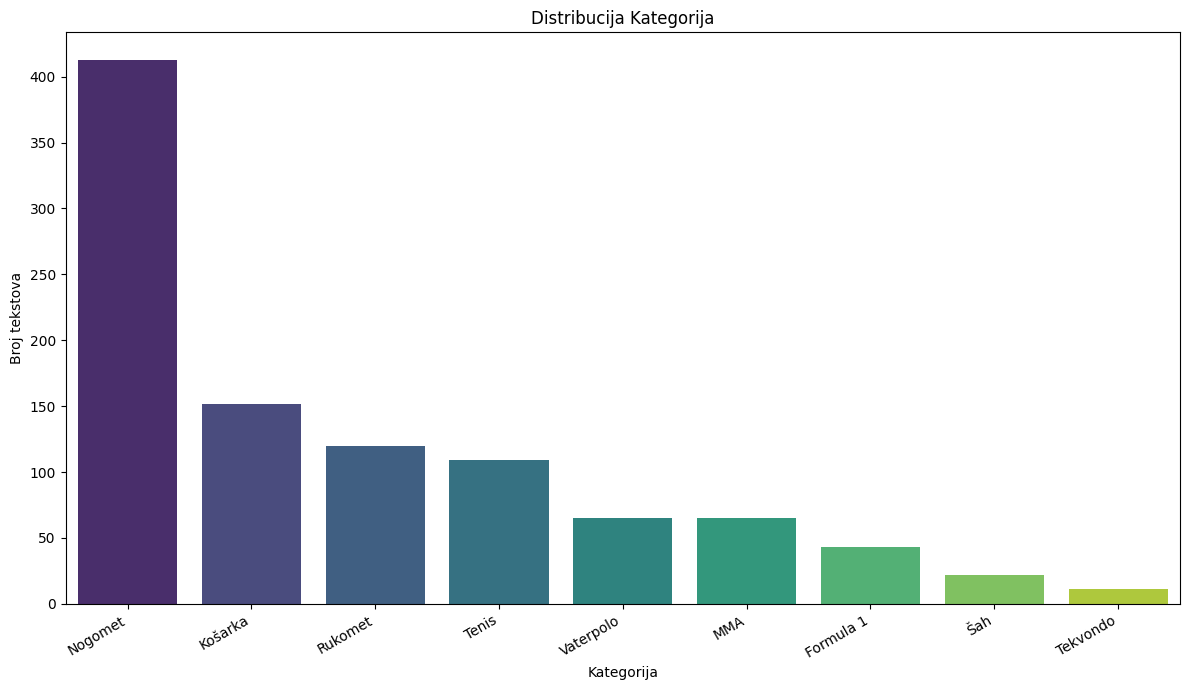

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

class_distribution = df['Kategorija'].value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=class_distribution.index, y=class_distribution.values, hue=class_distribution.index, palette='viridis', legend=False)
plt.title('Distribucija Kategorija')
plt.xlabel('Kategorija')
plt.ylabel('Broj tekstova')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [8]:
!pip install -q spacy
!python -m spacy download hr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 54.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('hr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
import spacy

nlp = spacy.load("hr_core_news_sm") # učitavanje gotovog modela

# Stop riječi (proširene za sportski dataset) jer neke prevladavaju
stop_rijeci = nlp.Defaults.stop_words

custom_stop = {
    "utakmica", "pobjeda","igrač", "momčad", "klub", "trener",
    "liga", "sezona", "kolo", "susret",
    "reprezentativac", "reprezentacija", "partija", "potez",
    "utrka", "vrijeme", "krug", "boksati",
    "koš", "dvorana",
    "gol", "navijač"
}

stop_rijeci = stop_rijeci.union(custom_stop)

In [10]:
def obradi_tekst(tekst):
    doc = nlp(str(tekst))

    tokeni = []

    for token in doc:
        if (
            token.is_alpha and
            not token.is_stop and
            not token.is_punct and
            token.lemma_ not in stop_rijeci
        ):
            tokeni.append(token.lemma_.lower())

    return tokeni

In [11]:
df["processed"] = df["Tekst"].apply(obradi_tekst) # primjena na dataset

df[["Tekst", "processed"]].head()

,Tekst,processed
0,Trener Simon Rožman bio je vidljivo zadovoljan...,"[simon, rožman, vidljiv, zadovoljan, nastup, s..."
1,Donna Vekić nastavlja sjajan nastup na turniru...,"[donna, vekić, nastavljati, sjajan, nastup, tu..."
2,Velika nagrada Formule 1 u Spa-Francorchamps p...,"[velik, nagrada, formula, spa, francorchamps, ..."
3,Veliki derbi između Osijek i Hajduk Split priv...,"[velik, derb, između, osijek, hajduk, split, p..."
4,"U uzbudljivoj utakmici 1. kola HNL-a, Dinamo Z...","[uzbudljivoj, hnl, dinamo, zagreb, teren, svla..."


In [12]:
# Spajanje u tekst (za ML modele)

df["processed_text"] = df["processed"].apply(lambda x: " ".join(x))

### Named Entity Recognition

NER on the raw text to identify and classify named entities like persons, organizations, and locations. This can provide valuable insights into the key subjects and themes discussed in the articles

In [14]:
def extract_entities(text):
    doc = nlp(str(text))
    entities = []
    for ent in doc.ents:
        entities.append((ent.text, ent.label_))
    return entities

df['named_entities'] = df['Tekst'].apply(extract_entities)

print("DataFrame with extracted Named Entities:")
display(df[['Tekst', 'named_entities']].head(10))

DataFrame with extracted Named Entities:


,Tekst,named_entities
0,Trener Simon Rožman bio je vidljivo zadovoljan...,"[(Simon Rožman, PER), (Hajduk, ORG), (Dinamo Z..."
1,Donna Vekić nastavlja sjajan nastup na turniru...,"[(Donna Vekić, PER), (Holger Rune, PER), (Tayl..."
2,Velika nagrada Formule 1 u Spa-Francorchamps p...,"[(Formule 1 u Spa-Francorchamps, ORG), (Alexan..."
3,Veliki derbi između Osijek i Hajduk Split priv...,"[(Veliki derbi, MISC), (Osijek, ORG), (Hajduk,..."
4,"U uzbudljivoj utakmici 1. kola HNL-a, Dinamo Z...","[(HNL-a, ORG), (Dinamo Zagreb, ORG), (Slaven B..."
5,Hrvatska vaterpolska reprezentacija priredila ...,"[(Hrvatska, LOC), (Mađarska, LOC), (Zvonimir B..."
6,"U uzbudljivoj utakmici 11. kola HNL-a, Osijek ...","[(HNL-a, ORG), (Varaždin, ORG), (Tin Jedvaj, P..."
7,Trener Mario Kovačević bio je vidljivo zadovol...,"[(Mario Kovačević, PER), (Reprezentativac, PER..."
8,Borba večeri na ONE Championship eventu pružil...,"[(Sean O'Malley, PER), (Sean O'Malley, PER), (..."
9,Rukometaši Poreč priredili su pravo iznenađenj...,"[(Paris Saint-Germain, MISC), (Knežević, PER),..."


In [15]:
from collections import Counter

# Flatten the list of entities and extract only the labels
all_labels = [label for sublist in df['named_entities'] for text, label in sublist]

# Count the frequency of each label
label_counts = Counter(all_labels)

print("Frequency of Named Entity Labels:")
display(pd.DataFrame(label_counts.items(), columns=['Label', 'Frequency']).sort_values(by='Frequency', ascending=False))

Frequency of Named Entity Labels:


,Label,Frequency
0,PER,3406
1,ORG,1810
2,LOC,980
3,MISC,289


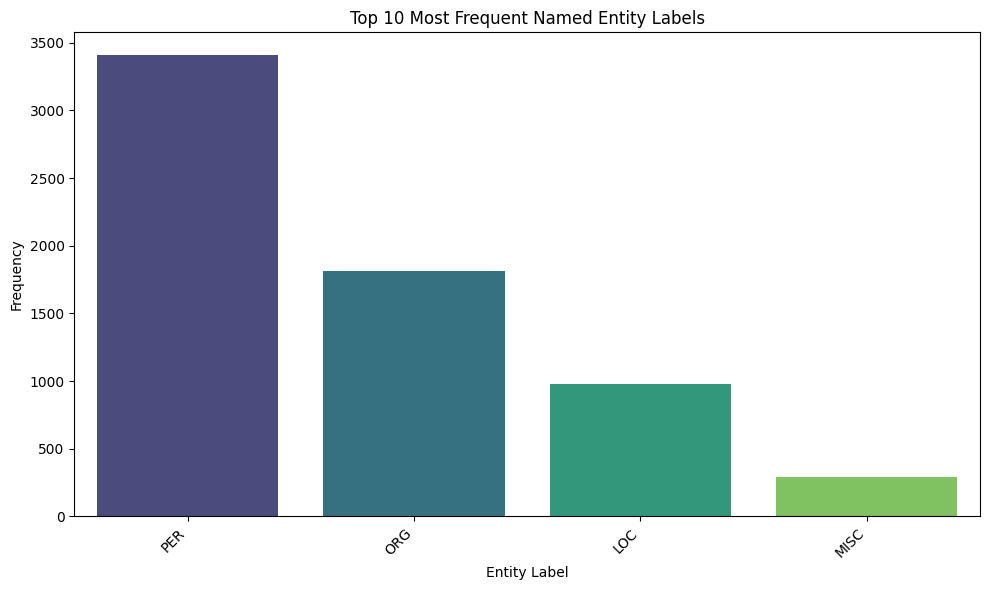

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Ensure all_labels is available, if not, re-extract (this is for robustness)
# all_labels = [label for sublist in df['named_entities'] for text, label in sublist]
# label_counts = Counter(all_labels)

# Get the top 10 most frequent entity labels
top_10_entities = label_counts.most_common(10)
top_10_df = pd.DataFrame(top_10_entities, columns=['Entity Label', 'Frequency'])

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Entity Label', y='Frequency', data=top_10_df, palette='viridis', hue='Entity Label', legend=False)
plt.title('Top 10 Most Frequent Named Entity Labels')
plt.xlabel('Entity Label')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
from collections import Counter

# Flatten all named entities
all_named_entities_flat = [entity for sublist in df['named_entities'] for entity in sublist]

# Filter for 'PER' (Person) and 'ORG' (Organization) entities
person_org_entities = [text for text, label in all_named_entities_flat if label in ['PER', 'ORG']]

# Count the frequency of each specific entity
entity_frequency = Counter(person_org_entities)

print("Top 20 Most Frequent Specific Named Entities (Persons & Organizations):")
display(pd.DataFrame(entity_frequency.most_common(20), columns=['Entity', 'Frequency']))

Top 20 Most Frequent Specific Named Entities (Persons & Organizations):


,Entity,Frequency
0,Lokomotiva,193
1,Slaven Belupo,172
2,Hajduk,148
3,Split,136
4,VAR,136
5,Varaždin,135
6,Dinamo Zagreb,120
7,Rijeka,117
8,HNL-a,98
9,Trener,81


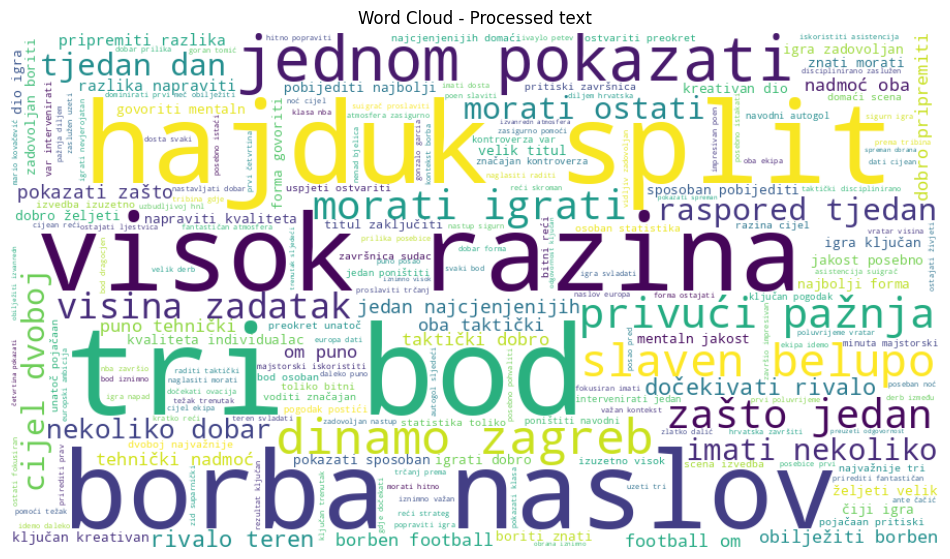

In [18]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine all processed text into a single string
all_words = ' '.join([text for text in df['processed_text']])

# Generate word cloud
wordcloud = WordCloud(width = 900, height = 500,
                random_state=21, max_font_size=120,
                background_color='white',
                stopwords=stop_rijeci # Use the custom stop words
               ).generate(all_words)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Processed text')
plt.show()

In [19]:
# TF-IDF (za klasifikaciju)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["processed_text"])
y = df["Kategorija"]

In [20]:
# jednostavna klasifikacija sportova

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.992


In [21]:
# Investigate potential data leakage in the features

feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_

for i, class_label in enumerate(model.classes_):
    top_n = 10  # Number of top features to display
    top_features_indices = coefs[i].argsort()[-top_n:][::-1]
    top_features = [feature_names[idx] for idx in top_features_indices]
    print(f"Top {top_n} features for class '{class_label}':\n{', '.join(top_features)}\n")

Top 10 features for class 'Formula 1':
poredak, pierre, gasly, svjetski, fernando, alonso, sekunda, pretvoriti, stratez, sposobnost

Top 10 features for class 'Košarka':
poen, impresivan, poseban, nba, četvrtina, serija, izvesti, parket, osigurati, izvanredn

Top 10 features for class 'MMA':
borba, runda, borac, večer, spreman, mma, sean, volkanovski, usman, jiří

Top 10 features for class 'Nogomet':
bod, dobro, šibenik, morati, jedan, rijeka, varaždin, forma, dinamo, hajduk

Top 10 features for class 'Rukomet':
obrana, prav, suparnički, pogotak, duah, pristup, kolektivan, trebati, maksimum, rukometan

Top 10 features for class 'Tekvondo':
nafia, kus, jun, jang, pozdravljati, burno, nacionalan, precizan, kruna, finals

Top 10 features for class 'Tenis':
turnir, meč, izvanredan, teniski, servis, đoković, novak, drugi, andrey, rublev

Top 10 features for class 'Vaterpolo':
hrvatska, slavlje, ovako, vaterpolski, hrvatski, vk, lako, moći, sjazan, muka

Top 10 features for class 'Šah':
jasa

In [22]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Formula 1       1.00      1.00      1.00        11
     Košarka       1.00      1.00      1.00        38
         MMA       1.00      1.00      1.00        16
     Nogomet       0.98      1.00      0.99       103
     Rukomet       1.00      1.00      1.00        30
    Tekvondo       1.00      0.33      0.50         3
       Tenis       1.00      1.00      1.00        27
   Vaterpolo       1.00      1.00      1.00        16
         Šah       1.00      1.00      1.00         6

    accuracy                           0.99       250
   macro avg       1.00      0.93      0.94       250
weighted avg       0.99      0.99      0.99       250



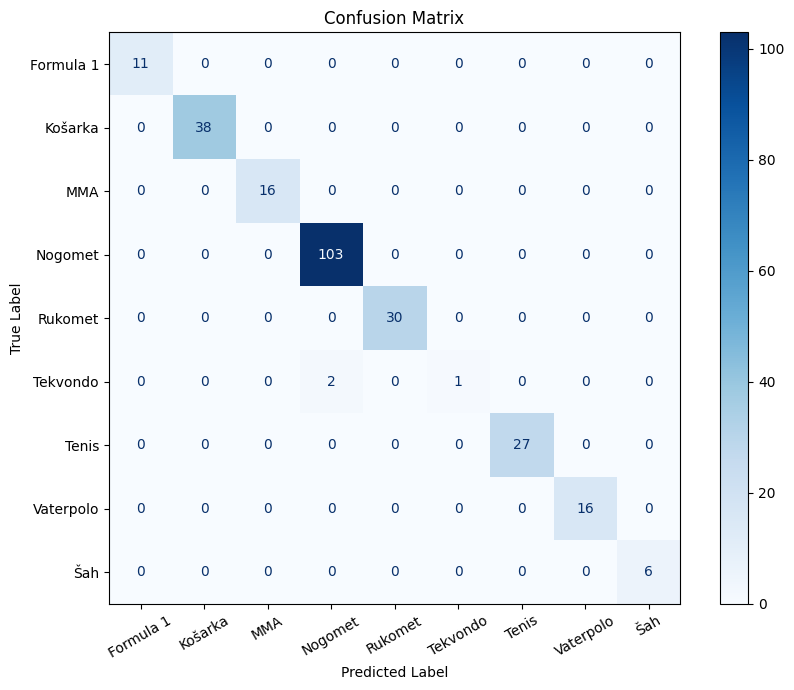

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=30)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# Filter DataFrame for 'Rukomet' and 'Nogomet'
rukomet_df = df[df['Kategorija'] == 'Rukomet']
nogomet_df = df[df['Kategorija'] == 'Nogomet']

# Initialize CountVectorizer (using the same max_features as TF-IDF for consistency if needed, or adjust)
count_vectorizer = CountVectorizer(max_features=5000)

# Fit and transform for Rukomet
X_rukomet = count_vectorizer.fit_transform(rukomet_df['processed_text'])
words_rukomet = count_vectorizer.get_feature_names_out()
counts_rukomet = X_rukomet.sum(axis=0)
freq_rukomet = pd.DataFrame({'Word': words_rukomet, 'Frequency': counts_rukomet.tolist()[0]}).sort_values(by='Frequency', ascending=False)

# Fit and transform for Nogomet
X_nogomet = count_vectorizer.fit_transform(nogomet_df['processed_text'])
words_nogomet = count_vectorizer.get_feature_names_out()
counts_nogomet = X_nogomet.sum(axis=0)
freq_nogomet = pd.DataFrame({'Word': words_nogomet, 'Frequency': counts_nogomet.tolist()[0]}).sort_values(by='Frequency', ascending=False)

print("\nTop 20 most frequent words in 'Rukomet' articles:")
display(freq_rukomet.head(20))

print("\nTop 20 most frequent words in 'Nogomet' articles:")
display(freq_nogomet.head(20))


Top 20 most frequent words in 'Rukomet' articles:


,Word,Frequency
78,obrana,162
100,prav,135
159,znati,89
127,sljedeći,87
32,hrvatski,83
132,suparnički,83
133,svaki,81
149,vratar,79
67,naglasiti,77
142,trenutak,72



Top 20 most frequent words in 'Nogomet' articles:


,Word,Frequency
62,igra,512
10,bod,394
109,morati,389
31,dobro,284
142,pokazati,278
86,ključan,277
190,taktički,277
81,jedan,272
166,reći,271
201,tri,271


### Key observations:

High Overall Accuracy: The model achieved an impressive overall accuracy of 0.99 (99%), indicating it correctly classified a large majority of the test samples.
Excellent Performance for Most Classes: Many categories, including 'Formula 1', 'Košarka', 'MMA', 'Rukomet', 'Tenis', 'Vaterpolo', and 'Šah', show perfect precision, recall, and F1-scores of 1.00. This means the model correctly identified all instances of these sports and rarely misclassified other sports as these.
Strong Performance for 'Nogomet': 'Nogomet' (football), which has the highest support (103 samples), also performs very well with a precision of 0.98, and perfect recall and F1-score of 0.99. This suggests the model is very good at identifying football-related texts.
Lower Performance for 'Tekvondo': The 'Tekvondo' (Taekwondo) category stands out with lower performance, particularly in recall (0.33) and F1-score (0.50). Although its precision is 1.00 (meaning all texts classified as 'Tekvondo' were indeed 'Tekvondo'), the low recall indicates that the model missed a significant portion of actual 'Tekvondo' texts (only correctly identifying 1 out of 3, as indicated by the support).
These results align with the previous investigation of potential data leakage, where highly unique keywords might be driving the high performance in most classes, especially those with perfect scores. The lower recall for 'Tekvondo' might suggest it has fewer unique identifying keywords, or the keywords are not as strong, leading to some 'Tekvondo' texts being missed by the classifier.

In [25]:
!pip install -q transformers

In [26]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from transformers import pipeline

# učitavanje multilingual sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# sentiment funkcija
def get_sentiment(text):
    if pd.isna(text) or text == '':
        return None
    result = sentiment_analyzer(text)
    # The model returns a list of dicts, e.g., [{'label': '5 stars', 'score': 0.999}]
    # We'll extract just the label (e.g., '5 stars')
    return result[0]['label']

# Apply sentiment analysis to the original 'Tekst' column
df['sentiment'] = df['Tekst'].apply(get_sentiment)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [27]:
# Display the DataFrame with the new sentiment column
display(df[['Tekst', 'sentiment']].head(20))

,Tekst,sentiment
0,Trener Simon Rožman bio je vidljivo zadovoljan...,4 stars
1,Donna Vekić nastavlja sjajan nastup na turniru...,5 stars
2,Velika nagrada Formule 1 u Spa-Francorchamps p...,4 stars
3,Veliki derbi između Osijek i Hajduk Split priv...,4 stars
4,"U uzbudljivoj utakmici 1. kola HNL-a, Dinamo Z...",4 stars
5,Hrvatska vaterpolska reprezentacija priredila ...,4 stars
6,"U uzbudljivoj utakmici 11. kola HNL-a, Osijek ...",4 stars
7,Trener Mario Kovačević bio je vidljivo zadovol...,3 stars
8,Borba večeri na ONE Championship eventu pružil...,2 stars
9,Rukometaši Poreč priredili su pravo iznenađenj...,4 stars


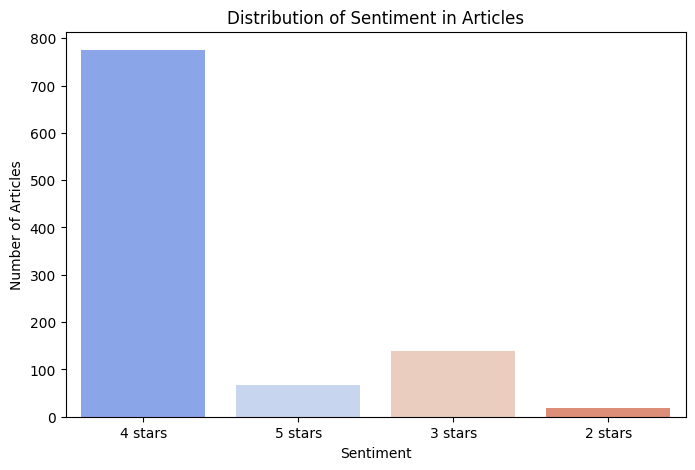

sentiment,2 stars,3 stars,4 stars,5 stars
Kategorija,,,,
Formula 1,6,2,26,9
Košarka,0,30,122,0
MMA,11,0,47,7
Nogomet,0,83,330,0
Rukomet,0,15,101,4
Tekvondo,0,0,5,6
Tenis,2,3,73,31
Vaterpolo,0,0,59,6
Šah,0,5,12,5


In [28]:
# Visualize the distribution of sentiment
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='coolwarm', hue='sentiment', legend=False)
plt.title('Distribution of Sentiment in Articles')
plt.xlabel('Sentiment')
plt.ylabel('Number of Articles')
plt.show()

# Show sentiment counts by category
sentiment_by_category = df.groupby('Kategorija')['sentiment'].value_counts().unstack(fill_value=0)
display(sentiment_by_category)

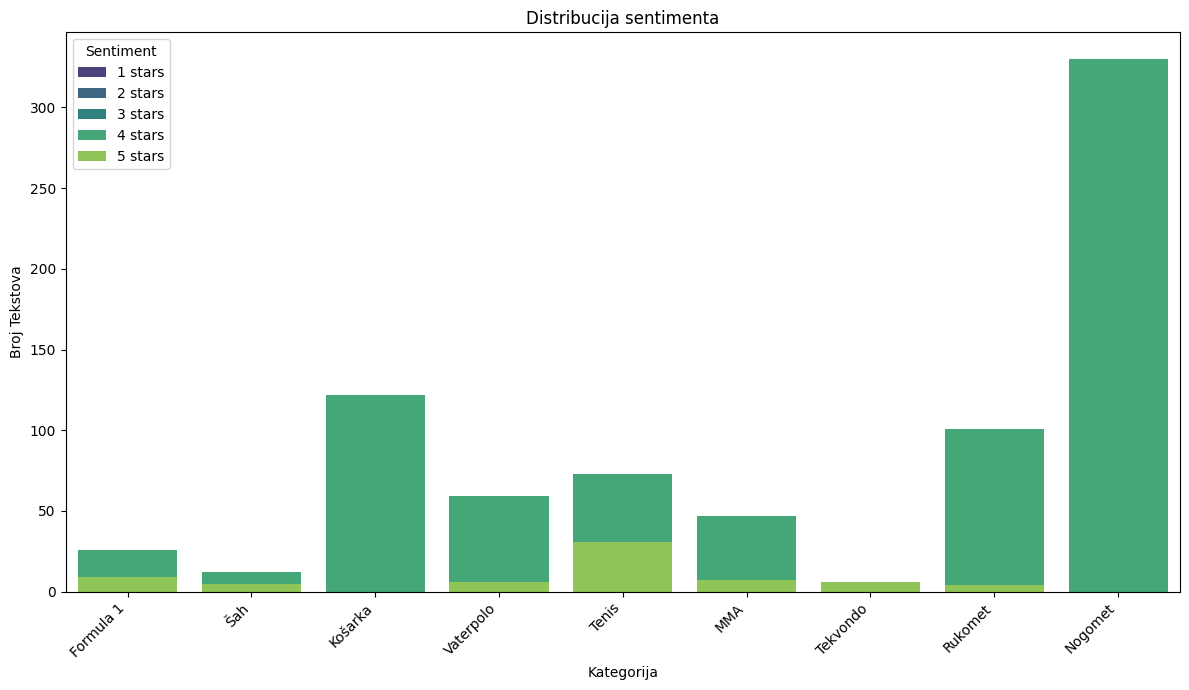

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for stacked bar chart
sentiment_by_category_plot = sentiment_by_category.stack().reset_index()
sentiment_by_category_plot.columns = ['Category', 'Sentiment', 'Count']

# Order sentiments for better visualization
sentiment_order = ['1 stars', '2 stars', '3 stars', '4 stars', '5 stars']
sentiment_by_category_plot['Sentiment'] = pd.Categorical(sentiment_by_category_plot['Sentiment'], categories=sentiment_order, ordered=True)
sentiment_by_category_plot = sentiment_by_category_plot.sort_values('Sentiment')

# Create the stacked bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Category',
    y='Count',
    hue='Sentiment',
    data=sentiment_by_category_plot,
    palette='viridis',
    dodge=False # This makes it a stacked bar chart
)

plt.title('Distribucija sentimenta')
plt.xlabel('Kategorija')
plt.ylabel('Broj Tekstova')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

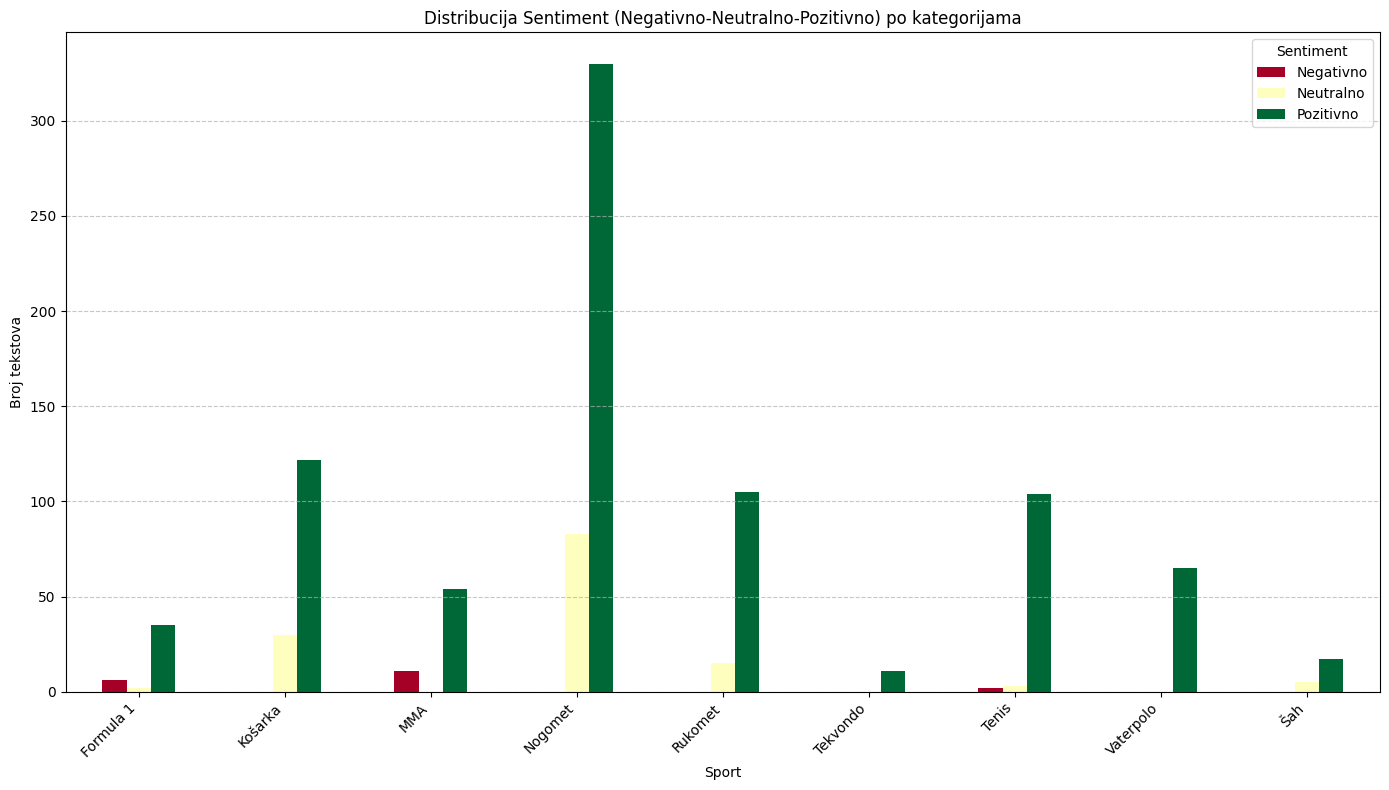

sentiment_simple,Negativno,Neutralno,Pozitivno
Kategorija,,,
Formula 1,6,2,35
Košarka,0,30,122
MMA,11,0,54
Nogomet,0,83,330
Rukomet,0,15,105
Tekvondo,0,0,11
Tenis,2,3,104
Vaterpolo,0,0,65
Šah,0,5,17


In [31]:
# Definiranje mapiranja zvjezdica u Sentiment kategorije
def map_sentiment_simple(label):
    if label in ['1 star', '2 stars', '1 stars']:
        return 'Negativno'
    elif label in ['3 stars']:
        return 'Neutralno'
    elif label in ['4 stars', '5 stars']:
        return 'Pozitivno'
    return 'Nepoznato'

# Primjena mapiranja
df['sentiment_simple'] = df['sentiment'].apply(map_sentiment_simple)

# Agregacija podataka za vizualizaciju
sentiment_simple_dist = df.groupby(['Kategorija', 'sentiment_simple']).size().unstack(fill_value=0)

# Normalizacija na postotke za bolju usporedbu (opcionalno, ali korisno)
sentiment_simple_pct = sentiment_simple_dist.div(sentiment_simple_dist.sum(axis=1), axis=0) * 100

# Vizualizacija
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
sentiment_simple_dist.plot(kind='bar', stacked=False, ax=plt.gca(), colormap='RdYlGn')

plt.title('Distribucija Sentiment (Negativno-Neutralno-Pozitivno) po kategorijama')
plt.xlabel('Sport')
plt.ylabel('Broj tekstova')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Prikaz tablice s brojkama
display(sentiment_simple_dist)

### Iz rezultata možemo primijetiti:

Izrazito pozitivni sportovi: Vaterpolo i Tekvondo imaju isključivo pozitivne vijesti (100%).
Mješoviti sentiment: Formula 1 i MMA pokazuju najveći udio negativnih vijesti, što je i očekivano s obzirom na prirodu tih sportova (incidenti, porazi, borbe).
Najviše podataka: Nogomet dominira s najvećim brojem tekstova, od kojih je velika većina pozitivna ili neutralna.

### Zero-Shot Text Classification

Let's explore zero-shot text classification to see how well a pre-trained model can classify the articles into the existing sport categories without any specific training on our dataset. We'll use a multilingual zero-shot classification model from the `transformers` library.

In [ ]:
from transformers import pipeline

# Load a zero-shot classification pipeline. A multilingual model is suitable here.
# 'MoritzLaurer/mDeBERTa-v3-base-mnli-fever-anli' is a good multilingual option for zero-shot classification.
# It's trained on NLI tasks, which makes it good at understanding textual entailment, useful for zero-shot.
zero_shot_classifier = pipeline("zero-shot-classification", model="joeddav/xlm-roberta-large-xnli")

# Get unique categories from the DataFrame to use as candidate labels
candidate_labels = df['Kategorija'].unique().tolist()
print(f"Candidate labels for zero-shot classification: {candidate_labels}")

# Define a function to apply zero-shot classification
def classify_text_zero_shot(text, labels):
    if pd.isna(text) or text == '':
        return None
    # The classifier returns a dictionary with 'sequence', 'labels', and 'scores'
    result = zero_shot_classifier(text, labels)
    # Return the label with the highest score
    return result['labels'][0]

# Apply zero-shot classification to a sample of the 'Tekst' column
# For demonstration, we'll apply it to the first 100 texts to avoid long computation times.
# For full dataset, remove .head(100) or run on a smaller sample initially.
print("Applying zero-shot classification to a sample of texts...")
df['zero_shot_prediction'] = df['Tekst'].apply(lambda x: classify_text_zero_shot(x, candidate_labels))

print("DataFrame with Zero-Shot Predictions:")
display(df[['Tekst', 'Kategorija', 'zero_shot_prediction']].head(10))

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Candidate labels for zero-shot classification: ['Nogomet', 'Tenis', 'Formula 1', 'Vaterpolo', 'MMA', 'Rukomet', 'Košarka', 'Šah', 'Tekvondo']
Applying zero-shot classification to a sample of texts...


Let's analyze the performance of the zero-shot classifier by comparing its predictions to the actual 'Kategorija' labels.

Zero-Shot Classification Report:
              precision    recall  f1-score   support

   Formula 1       0.61      0.40      0.48        43
     Košarka       0.46      0.27      0.34       152
         MMA       0.76      0.63      0.69        65
     Nogomet       0.69      0.66      0.67       413
     Rukomet       0.71      0.74      0.72       120
    Tekvondo       0.77      0.91      0.83        11
       Tenis       0.74      0.87      0.80       109
   Vaterpolo       0.49      1.00      0.66        65
         Šah       0.58      0.82      0.68        22

    accuracy                           0.65      1000
   macro avg       0.64      0.70      0.65      1000
weighted avg       0.65      0.65      0.64      1000

Zero-Shot Accuracy: 0.6500


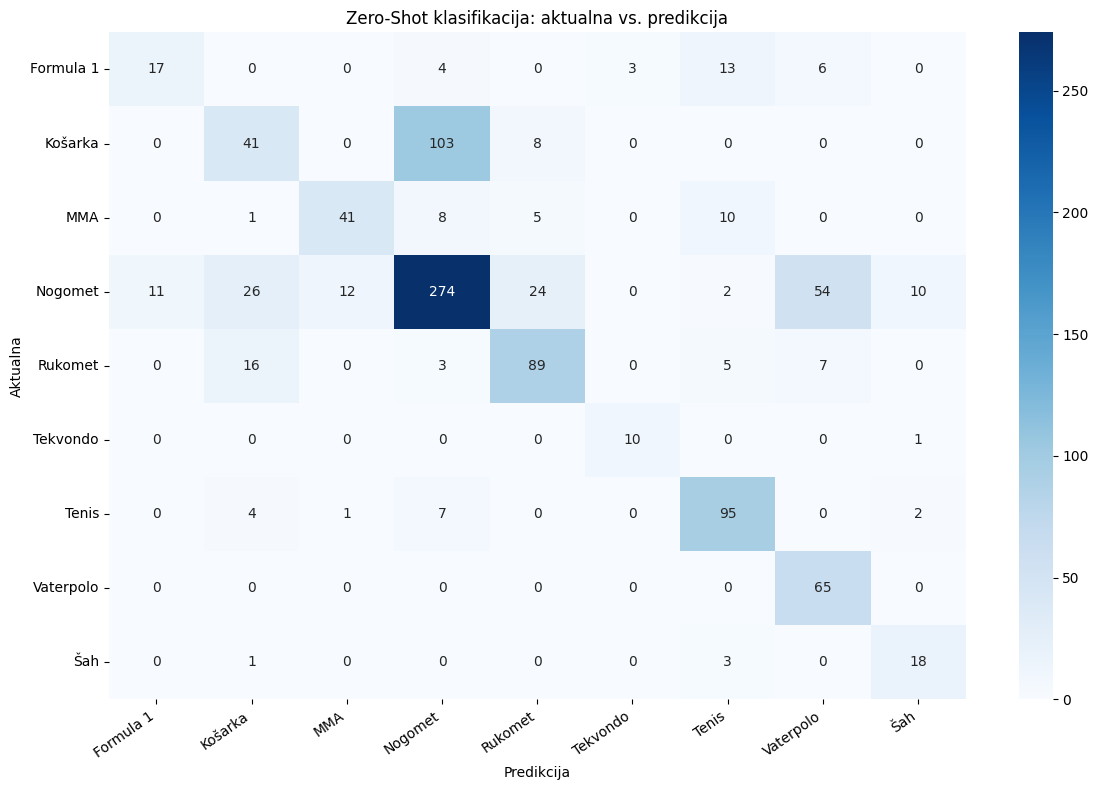

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Filter out rows where zero_shot_prediction is None (if any empty texts were present)
predicted_df = df.dropna(subset=['zero_shot_prediction'])

# Compare actual vs. predicted for the processed sample
y_true_zero_shot = predicted_df['Kategorija']
y_pred_zero_shot = predicted_df['zero_shot_prediction']

print("Zero-Shot Classification Report:")
print(classification_report(y_true_zero_shot, y_pred_zero_shot, zero_division=0))
print(f"Zero-Shot Accuracy: {accuracy_score(y_true_zero_shot, y_pred_zero_shot):.4f}")

# Visualize the agreement between actual and predicted categories
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab(y_true_zero_shot, y_pred_zero_shot), annot=True, fmt='d', cmap='Blues')
plt.title('Zero-Shot klasifikacija: aktualna vs. predikcija')
plt.xlabel('Predikcija')
plt.ylabel('Aktualna')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### The 'predictions' from the Zero-Shot Classification show how well the pre-trained model could classify your articles into the sports categories without any specific training on your dataset. Here's a summary of its performance:

Overall Accuracy: The model achieved an accuracy of 65.00%.
Strengths: It performed particularly well in identifying 'Tekvondo' (91% recall), 'Tenis' (87% recall), and 'Vaterpolo' (100% recall) articles. This suggests the model found distinct patterns for these categories.
Weaknesses: The model struggled more with 'Formula 1' (40% recall) and 'Košarka' (27% recall), indicating it had difficulty correctly identifying all articles belonging to these sports in a zero-shot setting.
This means that while the model could make reasonable predictions for many categories, its performance varies, highlighting the challenges of zero-shot learning on a diverse dataset.

Identify categories where the zero-shot model had the lowest precision
Analyzing the Zero-Shot Classification Report, the categories where the zero-shot model had the lowest precision are:

Vaterpolo: 0.49 precision
Šah: 0.58 precision
Formula 1: 0.61 precision
Košarka: 0.46 precision
'Košarka' had the absolute lowest precision at 0.46, followed closely by 'Vaterpolo' at 0.49. This indicates that for these categories, when the model predicted an article belonged to them, it was often incorrect.

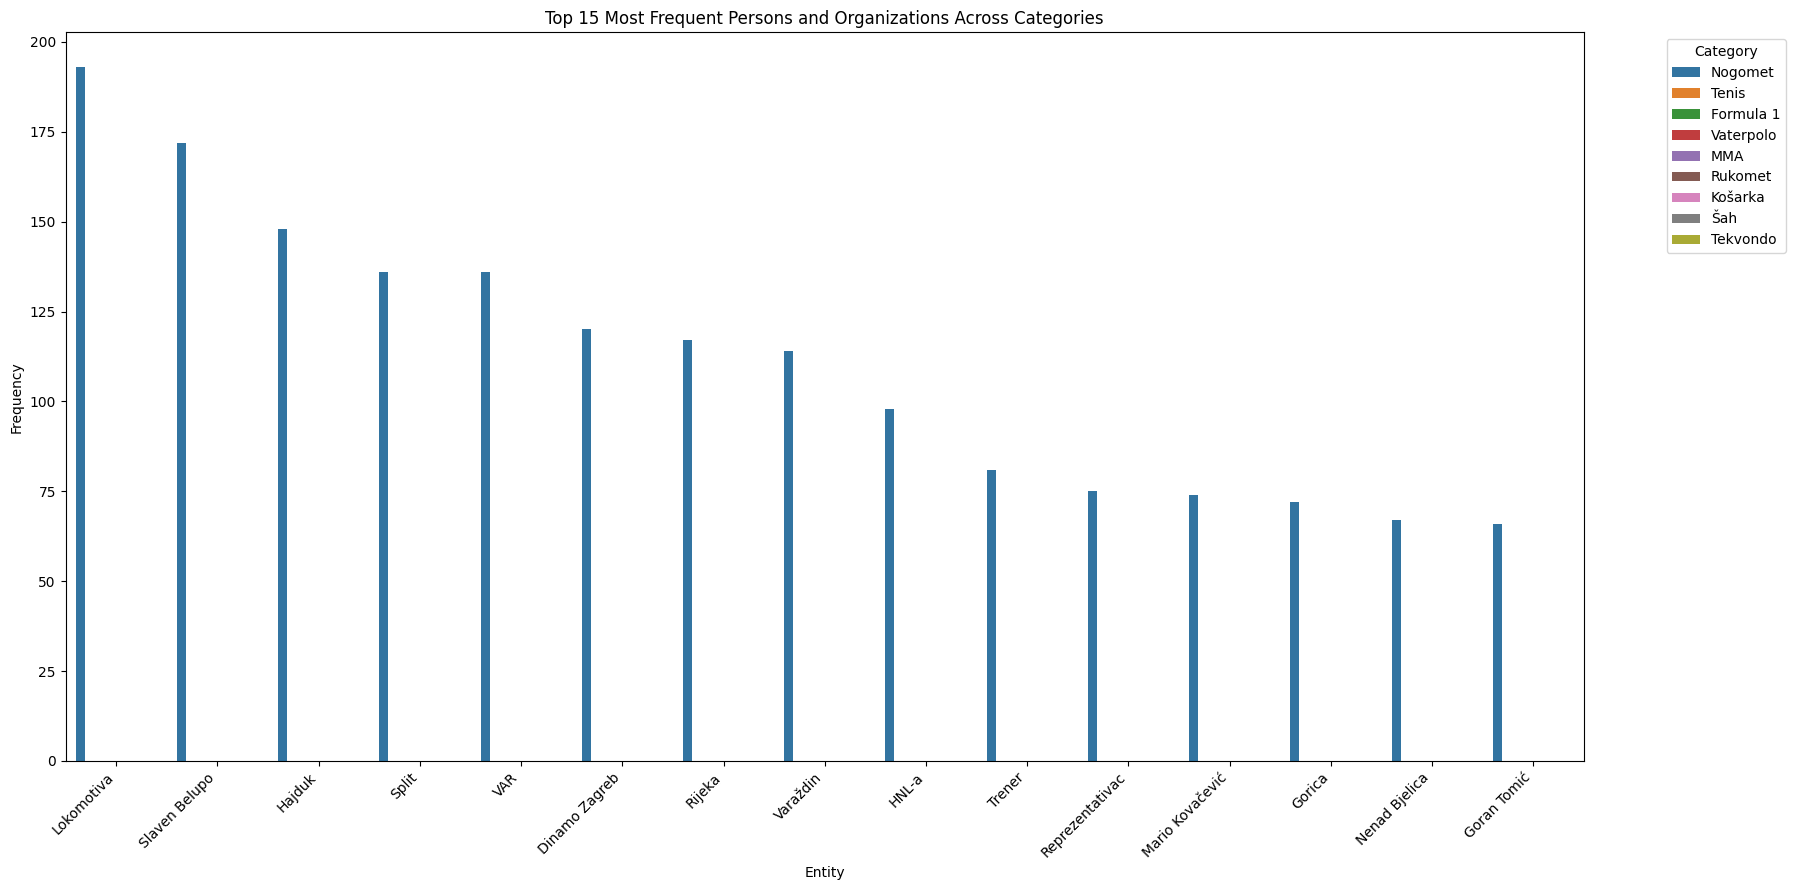

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten all named entities and filter for PER/ORG
all_named_entities_flat = [entity for sublist in df['named_entities'] for entity in sublist]
person_org_entities = [entity for entity in all_named_entities_flat if entity[1] in ['PER', 'ORG']]

# Count global frequency of PER/ORG entities
global_entity_frequency = Counter(person_org_entities)

# Select top N global entities to plot
top_n = 15 # You can adjust this number
top_global_entities = [entity for entity, count in global_entity_frequency.most_common(top_n)]

# Prepare data for comparative plot
plot_data = []
for category in df['Kategorija'].unique():
    category_df = df[df['Kategorija'] == category]
    # Ensure only PER/ORG entities are considered within each category for consistency
    category_entities_flat = [entity for sublist in category_df['named_entities'] for entity in sublist if entity[1] in ['PER', 'ORG']]
    category_entity_counts = Counter(category_entities_flat)

    for entity_tuple in top_global_entities:
        plot_data.append({
            'Category': category,
            'Entity': entity_tuple[0], # Just the text, not the (text, label) tuple
            'Label': entity_tuple[1],
            'Frequency': category_entity_counts.get(entity_tuple, 0)
        })

plot_df = pd.DataFrame(plot_data)

# Create the comparative grouped bar chart
plt.figure(figsize=(18, 9))
sns.barplot(data=plot_df, x='Entity', y='Frequency', hue='Category', palette='tab10')
plt.title(f'Top {top_n} Most Frequent Persons and Organizations Across Categories')
plt.xlabel('Entity')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The comparative bar chart showing the Top 15 Most Frequent Persons and Organizations Across Categories has been successfully generated. This visualization allows us to see which entities are most commonly mentioned and in which sports categories they appear.

From the chart, we can observe:

Dominant Entities in Nogomet: Entities like 'Lokomotiva', 'Slaven Belupo', 'Hajduk', 'Split', 'VAR', 'Dinamo Zagreb', and 'Rijeka' are prominently featured and almost exclusively tied to the 'Nogomet' (football) category, which aligns with them being football clubs or related terms.
Common Managerial Figures: 'Trener' (Coach) and 'Reprezentativac' (National Team Player) appear across multiple categories but are most frequent in 'Nogomet' and 'Rukomet'.
Specific Individuals: 'Mario Kovačević', 'Nenad Bjelica', and 'Goran Tomić' are identified as persons primarily within the 'Nogomet' context.
This chart visually confirms the strong association of certain entities with specific sports, providing a clear picture of the key players and organizations within each domain.

In [ ]:
!pip install -q pyLDAvis

In [ ]:
# pyLDAvis Visualization of LDA Model

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

df = pd.read_csv("sportnews_gpt_1000.csv")

# vektorizacija teksta
hr_stop_words = ['je', 'u', 'na', 'i', 'da', 'se', 'za', 'od', 'koji', 'su', 's', 'a', 'to', 'iz', 'što']
vectorizer = CountVectorizer(max_df=0.90, min_df=2, stop_words=hr_stop_words)
dtm = vectorizer.fit_transform(df['Tekst'])

# treniranje
lda = LatentDirichletAllocation(n_components=9, random_state=42)
lda.fit(dtm)

# prikaz u notebooku
print("Generiram vizualizaciju...")
vizualizacija = pyLDAvis.lda_model.prepare(lda, dtm, vectorizer)
pyLDAvis.display(vizualizacija)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Generiram vizualizaciju...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Interpret the pyLDAvis visualization
The pyLDAvis visualization is an interactive tool that helps you interpret the topics extracted by your LDA model. Here's a breakdown of how to interpret its key components:

1. Intertopic Distance Map (Left Panel):

Circles: Each circle represents a topic. The size of the circle corresponds to the overall prevalence of that topic in the corpus.
Distance: The distance between the centers of the circles indicates the similarity between topics. Topics that are closer together are more similar in terms of their word distributions. Conversely, topics far apart are quite distinct.
Axes (PC1, PC2): These are the principal components that capture the most variance in the topic-word distributions, allowing for a 2D representation of higher-dimensional data.
Hovering/Clicking: When you hover over or click a topic circle, the right panel updates to show the most relevant words for that specific topic.
2. Bar Chart of Word Importance (Right Panel):

Most Relevant Words for Selected Topic: This bar chart displays the top words for the topic currently selected in the left panel.
Two Metrics:
Red Bars (Global Frequency): This indicates how frequently a word appears in the entire corpus, regardless of topic.
Blue Bars (Estimated Term Frequency within the Selected Topic): This shows how frequently a word appears within the selected topic.
Slider (λ - Lambda): This is a crucial control. It allows you to adjust the weighting of the two metrics (global frequency vs. topic-specific frequency) when determining the 'relevance' of a word.
λ closer to 1 (e.g., 1): Words are ranked primarily by their lift (ratio of topic-specific frequency to corpus-wide frequency). This highlights words that are unique to the topic, even if they aren't super frequent overall.
λ closer to 0 (e.g., 0): Words are ranked primarily by their topic-specific frequency. This shows the most frequent words within the topic, which might also be frequent in other topics or the overall corpus.
Interpreting with λ: Experiment with different λ values to see how the most 'relevant' words change. A word that remains high for both low and high λ values is generally a strong indicator of that topic.
How to Use it for Interpretation:

Identify Distinct Topics: Look for well-separated circles on the left. These represent distinct underlying themes in your data.
Explore Topic Content: Click on each circle to see the associated words in the right panel. Adjust the λ slider to understand what makes these words relevant to the topic (uniqueness vs. frequency).
Name Your Topics: Based on the most relevant words, you can infer what each topic is about and assign a meaningful name (e.g., "Football News", "Tennis Matches").
Check for Overlap: If circles are very close or overlapping, it suggests that those topics might be similar or that your chosen number of topics (num_topics) might be too high, leading to redundant topics.
Look for Outliers: Very small or isolated circles might indicate niche topics or topics that are not very well-defined by the model.
By interactively exploring the visualization, you can gain a deep understanding of the semantic structure of your textual data.

In [ ]:
def display_top_words_per_topic(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
        print()

n_top_words = 10
feature_names = vectorizer.get_feature_names_out()

display_top_words_per_topic(lda, feature_names, n_top_words)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Topic 1:
hrvatska bila bio bili momčad obrani vratar trener pravi suparničke

Topic 2:
borba sam bila sve rekao borbu bio boraca već borbi

Topic 3:
bio bila utrka sve sekundi savršeno spreman ovu do kraju

Topic 4:
utakmica ali momčad bila posebno niz smo trener pohvalio znali

Topic 5:
pobjedu poena pokazao nba završio još igre svoju cijelu bila

Topic 6:
momčadi igre utakmica zadovoljan tehničke bez sam ove nije ali

Topic 7:
jednom još nakon bila visokoj cijeli kroz razini rekao dvoboj

Topic 8:
bio meč svaki ali pobjedu sam turniru pokazao rekao igru

Topic 9:
navijači trener naglasio momčad bio momčadi gol postigao ga rekao



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag